<a href="https://colab.research.google.com/github/ASHVISH03/GEN-AI-LAB-EXPERIMENTS/blob/main/GenAiExpt10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers torch pillow

In [2]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import BlipProcessor, BlipForQuestionAnswering

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
).to(device)

print("BLIP model loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

BLIP model loaded successfully.


Saving bca02107-19d7-4072-a70d-0dfd296d6b39.png to bca02107-19d7-4072-a70d-0dfd296d6b39.png
Enter a question about the image: What is shown in the image?


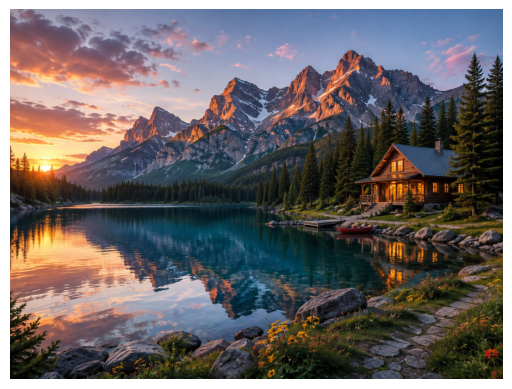

Question: What is shown in the image?
Answer: mountains


In [4]:
uploaded = files.upload()
image_path = next(iter(uploaded))

image = Image.open(image_path).convert("RGB")
question = input("Enter a question about the image: ")

inputs = processor(
    images=image,
    text=question,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=20)

answer = processor.decode(output[0], skip_special_tokens=True)

plt.imshow(image)
plt.axis("off")
plt.show()

print("Question:", question)
print("Answer:", answer)